In [1]:
pip install imageio==2.4.1

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 3.3 MB 7.6 MB/s 
  Created wheel for imageio: filename=imageio-2.4.1-py3-none-any.whl size=3303885 sha256=eeedb05f2bff4a41833f93c27895eb4cd5c210f0efadea965670c8c61af29c9f
  Stored in directory: /root/.cache/pip/wheels/46/20/07/7bb9c8c44e6ec2efa60fd0e6280094f53f65f41767ef69a5ee
Successfully built imageio
  Attempting uninstall: imageio
    Found existing installation: imageio 2.9.0
    Uninstalling imageio-2.9.0:
      Successfully uninstalled imageio-2.9.0


In [2]:
from __future__ import division
import numpy as np
import scipy.special as sc
import matplotlib.pyplot as plt
import os
import shutil
import cv2
import glob
import itertools
import math 
import imageio
from math import sqrt
from random import randint
from tqdm import tqdm
from scipy.special import gammainc
from numba import njit, jit, cuda, float32
import moviepy.editor as moviepy
from moviepy.editor import VideoFileClip
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Imageio: 'ffmpeg-linux64-v3.3.1' was not found on your computer; downloading it now.
Try 1. Download from https://github.com/imageio/imageio-binaries/raw/master/ffmpeg/ffmpeg-linux64-v3.3.1 (43.8 MB)
Downloading: 8192/45929032 bytes (0.0%)3768320/45929032 bytes (8.2%)7872512/45929032 bytes (17.1%)12058624/45929032 bytes (26.3%)15376384/45929032 bytes (33.5%)18628608/45929032 bytes (40.6%)21921792/45929032 bytes (47.7%)26075136/45929032 bytes (56.8%)30138368/45929032 bytes (65.6%)34373632/45929032 bytes (74.8%)38256640/45929032 bytes (83.3%)42344448/45929032 bytes (92.2%)45929032/45929032 bytes (100.0%)
  Done
File saved as /root

In [3]:
T0=10
N=288
rho=0.1
L0=np.round((N/rho)**(1/2), 1)
#rho=np.round(N/(L0**3),2)
v0=0.05
v_max=3.0*v0
r=3.0
r_rep=1.0
c_rep=0.2
eta=np.pi/10
mu=1.0
s=mu/5
dt=1.0
dit=5
BpG=72
tpB=4
T=806
random_number=randint(0,1000)
center = np.array([0,0])
blocks_per_grid = (BpG,1)
threads_per_block = (tpB,2)

print(L0)

txt='N='+str(N)+', L='+str(L0)+', rho='+str(rho)+', eta='+str(np.round(eta,2))+', r='+str(r)+', v0='+str(v0)+', c_rep='+str(c_rep)+ ', r_rep='+str(r_rep)+' ,mu='+str(mu)+', s='+str(s)

dir = os.path.join('/content/drive/My Drive/Frames/')
if os.path.exists(dir):
    shutil.rmtree(dir)

dir = os.path.join('/content/drive/My Drive/Frames/')
if not os.path.exists(dir):
    os.mkdir(dir)

53.7


In [4]:
#Ploting
def Simulation_plot(k, X, U):
    
    
    fig, ax = plt.subplots(figsize=(12,12))

    ax.set_xlabel('X - axis', fontsize=14)
    ax.set_ylabel('Y - axis', fontsize=14)


    ax.scatter(X[k,:,0],X[k,:,1], linewidths=0.1, color='blue')
    ax.quiver(X[k,:,0],X[k,:,1], U[k,:,0],U[k,:,1], color='black')

    fig.text(.5, .05, txt, ha='center',fontsize=14, linespacing=0.2)
   
    plt.xlim(0,L0)
    plt.ylim(0,L0)

    k= (k//dit)+1
    plt.savefig('/content/drive/My Drive/Frames/frame_VEM'+str(k)+'.png')
        
    plt.close()   
    return

In [5]:
#Calculation of the noise

def Add_noise(U):
    noise =np.random.uniform(low=-eta, high=eta, size=(N,1)).astype('float32')

    for i in range(N):

        norm_v = sqrt(U[i,0]**2+U[i,1]**2)
        theta = np.arctan2(U[i,1],U[i,0]) + noise[i]
        U[i,0]= norm_v * np.cos(theta)
        U[i,1]= norm_v * np.sin(theta)
     
    return U  


In [6]:
#Normalizing velocity
@cuda.jit
def normalized_U(a,out): 
  
    i, j = cuda.grid(2)
    d1, d2 = cuda.gridsize(2)
  
    for i1 in range(i, a.shape[0], d1): 
        for i2 in range(j, a.shape[1], d2):
            out[i1,i2] = v0*a[i1,i2]/sqrt(a[i1,0]**2 + a[i1,1]**2)    

In [7]:
#Normalizing velocity
@cuda.jit
def limited_U(a,out): 

    i, j = cuda.grid(2)
    d1, d2 = cuda.gridsize(2)

    for i1 in range(i, a.shape[0], d1): 
        for i2 in range(j, a.shape[1], d2):
            if sqrt(a[i1,0]**2 + a[i1,1]**2) > v_max:
                out[i1,i2] = v_max*a[i1,i2]/sqrt(a[i1,0]**2 + a[i1,1]**2)

In [8]:
#Calculation of the Order Parameter
@cuda.jit
def order_parameter(a,c,out): 
  
    i, j = cuda.grid(2)
    d1, d2= cuda.gridsize(2)

    for i1 in range(i, a.shape[0], d1):
        for i2 in range(j, a.shape[1], d2):
            c[i1,i2] = a[i1,i2]/sqrt(a[i1,0]**2 + a[i1,1]**2)


    k = cuda.grid(1)
    d3 = cuda.gridsize(1)
    for j1 in range(k, a.shape[1], d3):
        sum=0
        for s in range(N):
            sum += c[s,j1]
        out[j1] = abs(sum/N)

In [9]:
#Calculation of the new position of the particles
@cuda.jit
def Update_X(a, U_in, out):

    i,j = cuda.grid(2)
    d1,d2 = cuda.gridsize(2)

    for i1 in range(i, a.shape[0], d1): 
        for i2 in range(j, a.shape[1], d2): 
            out[i1,i2] = (a[i1,i2] + U_in[i1,i2]*dt)%L0


In [10]:
@cuda.jit
def U_average(U, A, m, k, n, out):

    i, j = cuda.grid(2)
    d1, d2 = cuda.gridsize(2)

    for i1 in range(i, N, d1):
        dm=m[i1]
        for i2 in range(j, 2, d2):
            sum = 0
            for s in range(N): 
                sum += A[i1, s]*U[dm,s ,i2]
            out[k,i1,i2]=(sum + U[k-1,i1,i2])/(n[i1,i2]+1)

In [11]:
#Calculation of the Adjacency Matrix
@cuda.jit
def Update_A(X, m, A_out):

    i1, j1 = cuda.grid(2)
    d1,d2 = cuda.gridsize(2)
  
    for i in range(i1, N, d1):
        dm=m[i]
        for j in range(j1, N, d2):

            dis1 = sqrt((X[dm,i,0]-X[dm,j,0])**2 + (X[dm,i,1]-X[dm,j,1])**2)
            dis2 = sqrt((X[dm,i,0]-(X[dm,j,0]-L0))**2 + (X[dm,i,1]-X[dm,j,1])**2) 
            dis3 = sqrt((X[dm,i,0]-(X[dm,j,0]+L0))**2 + (X[dm,i,1]-X[dm,j,1])**2)
            dis4 = sqrt((X[dm,i,0]-(X[dm,j,0]-L0))**2 + (X[dm,i,1]-(X[dm,j,1]-L0))**2)
            dis5 = sqrt((X[dm,i,0]-(X[dm,j,0]+L0))**2 + (X[dm,i,1]-(X[dm,j,1]-L0))**2)
            dis6 = sqrt((X[dm,i,0]-X[dm,j,0])**2 + (X[dm,i,1]-(X[dm,j,1]-L0))**2) 
            dis7 = sqrt((X[dm,i,0]-(X[dm,j,0]+L0))**2 + (X[dm,i,1]-(X[dm,j,1]+L0))**2)
            dis8 = sqrt((X[dm,i,0]-X[dm,j,0])**2 + (X[dm,i,1]-(X[dm,j,1]+L0))**2)
            dis9 = sqrt((X[dm,i,0]-(X[dm,j,0]-L0))**2 + (X[dm,i,1]-(X[dm,j,1]+L0))**2)

            dismin=min(dis1, dis2, dis3, dis4, dis5, dis6, dis7, dis8, dis9)
            
            if i!=j and dismin <= r:
                A_out[i,j] = 1 

In [12]:
def count_n(A):

    n1=(A == 1).sum(axis=1)
    return n1

In [13]:
#Calculation of the Repulsion term
@cuda.jit
def U_repulsion(X, U, m, U_out):
  
    i1, j1 = cuda.grid(2)

    d1,d2 = cuda.gridsize(2)
  
    for i in range(i1, N, d1):
        dm=m[i]
        for j in range(j1, N, d2):
            if i!=j:
                a1 = X[dm,i,0]-X[dm,j,0]
                b1 = X[dm,i,1]-X[dm,j,1]
                dis1 = sqrt(a1**2 + b1**2) + 0.00001

                a2 = X[dm,i,0]-(X[dm,j,0]-L0)
                b2 = X[dm,i,1]-X[dm,j,1]
                dis2 = sqrt(a2**2 + b2**2) 

                a3 = X[dm,i,0]-(X[dm,j,0]-L0)
                b3 = X[dm,i,1]-(X[dm,j,1]-L0)
                dis3 = sqrt(a3**2 + b3**2) 

                a4 = X[dm,i,0]-X[dm,j,0]
                b4 = X[dm,i,1]-(X[dm,j,1]-L0)
                dis4 = sqrt(a4**2 + b4**2)

                a5 = X[dm,i,0]-(X[dm,j,0]+L0)
                b5 = X[dm,i,1]-(X[dm,j,1]-L0)
                dis5 = sqrt(a5**2 + b5**2)  

                a6 = X[dm,i,0]-(X[dm,j,0]+L0)
                b6 = X[dm,i,1]-X[dm,j,1]
                dis6 = sqrt(a6**2 + b6**2) 

                a7=X[dm,i,0]-(X[dm,j,0]+L0)
                b7=X[dm,i,1]-(X[dm,j,1]+L0)
                dis7 = sqrt(a7**2 + b7**2) 

                a8=X[dm,i,0]-X[dm,j,0]
                b8=X[dm,i,1]-(X[dm,j,1]+L0)
                dis8 = sqrt(a8**2 + b8**2) 

                a9=X[dm,i,0]-(X[dm,j,0]-L0)
                b9=X[dm,i,1]-(X[dm,j,1]+L0)
                dis9 = sqrt(a9**2 + b9**2) 

                dismin=min(dis1, dis2, dis3, dis4, dis5, dis6, dis7, dis8, dis9)

      
                if dismin < 2*r_rep:

                    if dismin == dis1:
                        U[i,0] += c_rep*(2*r_rep - dis1) * a1/dis1
                        U[i,1] += c_rep*(2*r_rep - dis1) * b1/dis1

                    elif dismin == dis2:
                        U[i,0] += c_rep*(2*r_rep - dis2) * a2/dis2
                        U[i,1] += c_rep*(2*r_rep - dis2) * b2/dis2

                    elif dismin == dis3:
                        U[i,0] += c_rep*(2*r_rep - dis3) * a3/dis3
                        U[i,1] += c_rep*(2*r_rep - dis3) * b3/dis3

                    elif dismin == dis4:
                        U[i,0] += c_rep*(2*r_rep - dis4) * a4/dis4
                        U[i,1] += c_rep*(2*r_rep - dis4) * b4/dis4

                    elif dismin == dis5:
                        U[i,0] += c_rep*(2*r_rep - dis5) * a5/dis5
                        U[i,1] += c_rep*(2*r_rep - dis5) * b5/dis5

                    elif dismin == dis6:
                        U[i,0] += c_rep*(2*r_rep - dis6) * a6/dis6
                        U[i,1] += c_rep*(2*r_rep - dis6) * b6/dis6

                    elif dismin == dis7:
                        U[i,0] += c_rep*(2*r_rep - dis7) * a7/dis7
                        U[i,1] += c_rep*(2*r_rep - dis7) * b7/dis7

                    elif dismin == dis8:
                        U[i,0] += c_rep*(2*r_rep - dis8) * a8/dis8
                        U[i,1] += c_rep*(2*r_rep - dis8) * b8/dis8

                    elif dismin == dis9:
                        U[i,0] += c_rep*(2*r_rep - dis9) * a9/dis9
                        U[i,1] += c_rep*(2*r_rep - dis9) * b9/dis9
                        

    U_out=U       

In [14]:
U=np.zeros((T,N,2), dtype=np.float32)
X=np.zeros((T,N,2), dtype=np.float32)
theta0=np.zeros(N)
op=np.zeros((T,2), dtype=np.float32)
 

#Defining particles' initial positions and velocities
X[0,:,:]=np.random.uniform(low=0, high=L0, size=(N,2)).astype('float32')

theta0=np.random.uniform(low=0, high=2*np.pi, size=(N)).astype('float32')

U[0,:,0]=v0*np.cos(theta0[:])
U[0,:,1]=v0*np.sin(theta0[:])

#Defining particles' initial velocities
#U[0,:,:]=np.random.uniform(low=-v0, high=v0, size=(N,2)).astype('float32')


#Defining particles delay time
Dt= np.random.normal(mu,s, size=(N)).astype(int)


#Calculation of initial order parameter
U_temp = U[0,:,:]
op_temp = op[0,:]
U_in = cuda.to_device(U_temp)
c= cuda.to_device(U_in)
op_out = cuda.to_device(op_temp)

order_parameter[blocks_per_grid, threads_per_block](U_in,c,op_out)
cuda.synchronize()
op[0,:] = op_out.copy_to_host().astype('float32')

  warn(NumbaPerformanceWarning(msg))



In [15]:
#calculation of new position and velocity for T0 timestep before applying interctions and delay. 

for k in tqdm(range(1,T0)):
    
#Updating particles velocities
    U[k,:,:] = U[k-1,:,:]

#Updating particles positions 
    X_temp=X[k-1,:,:]
    U_temp=U[k,:,:]
    X_in = cuda.to_device(X_temp)
    X_out = cuda.to_device(X_in)
    U_in = cuda.to_device(U_temp)

    Update_X[blocks_per_grid, threads_per_block](X_in,U_in,X_out)
    X[k,:,:] = X_out.copy_to_host()

#Ploting
    if dit==1:
        Simulation_plot(k,X,U)
    elif k%dit ==1:
        Simulation_plot(k,X,U)
    

#Calculation of order parameter

    U_temp = U[k,:,:]
    op_temp = op[k,:]
    U_in = cuda.to_device(U_temp)
    c= cuda.to_device(U_in)
    op_out = cuda.to_device(op_temp)

    order_parameter[blocks_per_grid, threads_per_block](U_in,c,op_out)
    cuda.synchronize()
    op[k,:] = op_out.copy_to_host().astype('float32') 



  0%|          | 0/9 [00:00<?, ?it/s]WARNING:py.warnings:/usr/local/lib/python3.7/dist-packages/numba/cuda/dispatcher.py:488: NumbaPerformanceWarning: Grid size 72 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))

100%|██████████| 9/9 [00:00<00:00, 10.48it/s]


In [16]:
#Calculating the particle positions and velocities after first T0 time step.
A = np.zeros((N,N))
m=np.zeros(N)

for k in tqdm(range(T0, T)):

    m = abs((k-abs(Dt)).astype(int)-1)   #delay time for each particle.
    U_rep=np.zeros((N,2), dtype=np.float32)

#Calculation of adjacency matrix
    
    if r > 0:
   
        X_in = cuda.to_device(X)
        A_out = cuda.to_device(A)

        Update_A[blocks_per_grid, threads_per_block](X_in, m, A_out)
        cuda.synchronize()
        A = A_out.copy_to_host()
   
        n=count_n(A)

 #Calculation of align velocities

        ntiled = np.tile(n.reshape(N,1),(1,2))

        U_in = cuda.to_device(U)
        out = cuda.to_device(U_in)
        A_in = cuda.to_device(A)
        ntiled_in = cuda.to_device(ntiled)

        
        U_average[blocks_per_grid, threads_per_block](U_in, A_in, m,k, ntiled_in, out)
        cuda.synchronize()
        U = out.copy_to_host().astype('float32')
        
        U_temp=U[k,:,:]
        U_in = cuda.to_device(U_temp)
        U_out = cuda.to_device(U_in)

        normalized_U[blocks_per_grid, threads_per_block](U_in,U_out)
        cuda.synchronize()
        U[k,:,:] = U_out.copy_to_host()
    else:
        U[k,:,:]=U[k-1,:,:]


#Adding repulsion term to the velocities
    if r_rep > 0:
                
        X_in = cuda.to_device(X)
        U_in = cuda.to_device(U_rep)
        Urep_out = cuda.to_device(U_in)

        U_repulsion[blocks_per_grid, threads_per_block](X_in, U_in, m, Urep_out)
        cuda.synchronize()
        U_rep = Urep_out.copy_to_host().astype('float32')

        U[k,:,:] += U_rep[:,:]

        U_temp=U[k,:,:]
        U_in = cuda.to_device(U_temp)
        U_out = cuda.to_device(U_in)
        limited_U[blocks_per_grid, threads_per_block](U_in,U_out)
        cuda.synchronize()
        U[k,:,:] = U_out.copy_to_host().astype('float32')

#Adding noise and normalization to the allowed maximum velocity
    if eta != 0:
        U_temp = U[k,:,:]
        U[k,:,:] = Add_noise(U_temp)

        
#Updating particles positions     
  
    X_temp=X[k-1,:,:]
    U_temp=U[k,:,:]
    X_in = cuda.to_device(X_temp)
    X_out = cuda.to_device(X_in)
    U_in = cuda.to_device(U_temp)

    Update_X[blocks_per_grid, threads_per_block](X_in,U_in,X_out)
    X[k,:,:] = X_out.copy_to_host()    


#Ploting
    if dit==1:
        Simulation_plot(k,X,U)
    elif k%dit==1:
        Simulation_plot(k,X,U)

    
#Calculation of order parameter
    U_temp = U[k,:,:]
    op_temp = op[k,:]
    U_in = cuda.to_device(U_temp)
    c= cuda.to_device(U_in)
    op_out = cuda.to_device(op_temp)

    order_parameter[blocks_per_grid, threads_per_block](U_in,c,op_out)
    cuda.synchronize()
    op[k,:] = op_out.copy_to_host().astype('float32')


  0%|          | 0/796 [00:00<?, ?it/s]WARNING:py.warnings:/usr/local/lib/python3.7/dist-packages/numba/cuda/dispatcher.py:488: NumbaPerformanceWarning: Grid size 72 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))

  warn(NumbaPerformanceWarning(msg))

  warn(NumbaPerformanceWarning(msg))

  warn(NumbaPerformanceWarning(msg))

  warn(NumbaPerformanceWarning(msg))

  warn(NumbaPerformanceWarning(msg))

  warn(NumbaPerformanceWarning(msg))

  warn(NumbaPerformanceWarning(msg))

  0%|          | 1/796 [00:03<45:33,  3.44s/it]WARNING:py.warnings:/usr/local/lib/python3.7/dist-packages/numba/cuda/cudadrv/devicearray.py:885: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))

100%|██████████| 796/796 [01:02<00:00, 12.69it/s]


In [17]:
#Calculating stationary order parameter
op_norm=np.sqrt(np.sum(op**2, axis=1))
sum=0
for i in range(T-int(T/5), T):
    sum+=op_norm[i]
op_stationary=np.round(sum/(int(T/5)), 3)
print(op_stationary)

0.973


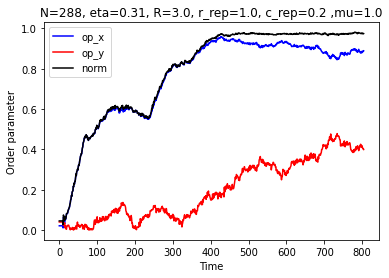

In [18]:
#plotting the graph of the order parameter

x = np.arange(0,T-1)
y1 = op[:,0]
y2 = op[:,1]

plt.title('N='+str(N)+', eta='+str(np.round(eta,2))+', R='+str(r)+', r_rep='+str(r_rep)+ ', c_rep='+str(c_rep)+' ,mu='+str(mu))
plt.ylabel("Order parameter") 
plt.xlabel("Time") 
plt.plot(x, y1[:-1], 'b', label='op_x')
plt.plot(x, y2[:-1], 'r', label='op_y')

plt.plot(x, np.sqrt(y1**2 + y2**2)[:-1], 'black', label='norm')

plt.savefig('/content/drive/My Drive/Order_parameter/N='+str(N)+', eta='+str(np.round(eta,2))+', R='+str(r)+', r_rep='+str(r_rep)+ ', c_rep='+str(c_rep)+' ,mu='+str(mu)+ ' ,T='+str(T)+ '.png')

plt.legend()
plt.show()

In [19]:
#making video
image_folder = '/content/drive/My Drive/Frames'
video_name = '/content/drive/My Drive/Videos/video.avi'
images=['frame_VEM'+str(k)+'.png' for k in range(1,(T//dit)+1)]
   
frame=cv2.imread(os.path.join(image_folder, images[0]))
height, width, layers = frame.shape
video = cv2.VideoWriter(video_name, 0, 15, (width,height))

for image in images:
    video.write(cv2.imread(os.path.join(image_folder, image)))

cv2.destroyAllWindows()
video.release()

In [20]:
clip = moviepy.VideoFileClip('/content/drive/My Drive/Videos/video.avi')
clip.write_videofile('/content/drive/My Drive/Videos/N'+str(N)+'_rho'+str(rho)+'_mu'+str(mu)+'_R'+str(r)+'_rrep'+str(r_rep)+'_crep'+str(c_rep)+'_eta'+str(np.round(eta,2))+'_v'+str(v0)+'_T='+str(T)+'.mp4')

[MoviePy] >>>> Building video /content/drive/My Drive/Videos/N288_rho0.1_mu1.0_R3.0_rrep1.0_crep0.2_eta0.31_v0.05_T=806.mp4
[MoviePy] Writing video /content/drive/My Drive/Videos/N288_rho0.1_mu1.0_R3.0_rrep1.0_crep0.2_eta0.31_v0.05_T=806.mp4


100%|██████████| 161/161 [00:04<00:00, 32.54it/s]


[MoviePy] Done.
[MoviePy] >>>> Video ready: /content/drive/My Drive/Videos/N288_rho0.1_mu1.0_R3.0_rrep1.0_crep0.2_eta0.31_v0.05_T=806.mp4 

